In [2]:
import json
import re
from datetime import datetime
from sentence_transformers import SentenceTransformer
import umap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import plotly.express as px
from sklearn.cluster import KMeans


# --- Load and extract user messages + timestamps from JSON ---
with open("conversations.json", "r", encoding="utf-8") as f:
    data = json.load(f)

user_messages = []
user_timestamps = []

for convo in data:
    mapping = convo.get("mapping", {})
    for msg in mapping.values():
        message = msg.get("message")
        if not message:
            continue
        author = message.get("author", {})
        if author.get("role") == "user":
            parts = message.get("content", {}).get("parts", [])
            timestamp = message.get("create_time")
            if parts and isinstance(parts[0], str):
                user_messages.append(parts[0])
                user_timestamps.append(timestamp)

# --- First-stage filter: short, duplicates, empty ---
raw_pairs = list(zip(user_messages, user_timestamps))

# Get unique pairs by converting to a set, then sort deterministically by timestamp
unique_pairs = sorted(list(set(raw_pairs)), key=lambda item: item[1])

# Now apply your filters
filtered_pairs = [
    (msg, ts) for msg, ts in unique_pairs
    if len(msg.split()) >= 7 and re.search(r'\w', msg)
]

# --- Second-stage filter: noisy/loggy/cody lines ---
def is_good_line(line):
    if len(line) > 500:
        return False
    if re.search(r"\$\s|^\(base\)|Traceback|File\s\"|\.py in <module>", line):
        return False
    if re.search(r"From:.*@.*\s|Subject:|^https?://", line):
        return False
    if re.search(r"(Caltech|NASA|Ureka|Ph\.D|Postdoctoral|Technical Skills|Experience|Resume)", line):
        return False
    if re.search(r"ValueError|matplotlib|pandas|ArrowInvalid", line, re.IGNORECASE):
        return False
    if re.match(r"^\(base\)|^\$|^ls\b|^git\b|^python\b", line):
        return False
    if re.search(r"\\cite|\{.*@.*\}|\bibliographystyle", line):
        return False
    if re.search(r"[a-zA-Z0-9_.+-]+@[a-zA-Z0-9-]+\.[a-zA-Z0-9-.]+", line):
        return False
    return True

# --- Final cleanup ---
cleaned_lines = []
cleaned_timestamps = []

for line, ts in filtered_pairs:
    line = line.replace("\n", " ").strip()
    if not is_good_line(line):
        continue
    line = re.sub(r"\(?\d{3}\)?[-.\s]?\d{3}[-.\s]?\d{4}", "[REDACTED]", line)
    line = re.sub(r"\bShooby\b|\bShoubaneh\b", "[REDACTED]", line)
    cleaned_lines.append(line)
    cleaned_timestamps.append(ts)

print(f"✅ Total user messages extracted: {len(user_messages)}")
print(f"✅ After filtering: {len(filtered_pairs)}")
print(f"✅ Final polished lines: {len(cleaned_lines)}")

timestamp_datetimes = [datetime.fromtimestamp(ts) for ts in cleaned_timestamps]


✅ Total user messages extracted: 9111
✅ After filtering: 6729
✅ Final polished lines: 4852


In [3]:
# Load sentence transformer
model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = model.encode(cleaned_lines)

# Optionally create a DataFrame for further use or visualization
df_embed = pd.DataFrame(embeddings)
df_embed["text"] = cleaned_lines
df_embed["timestamp"] = timestamp_datetimes


/opt/anaconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


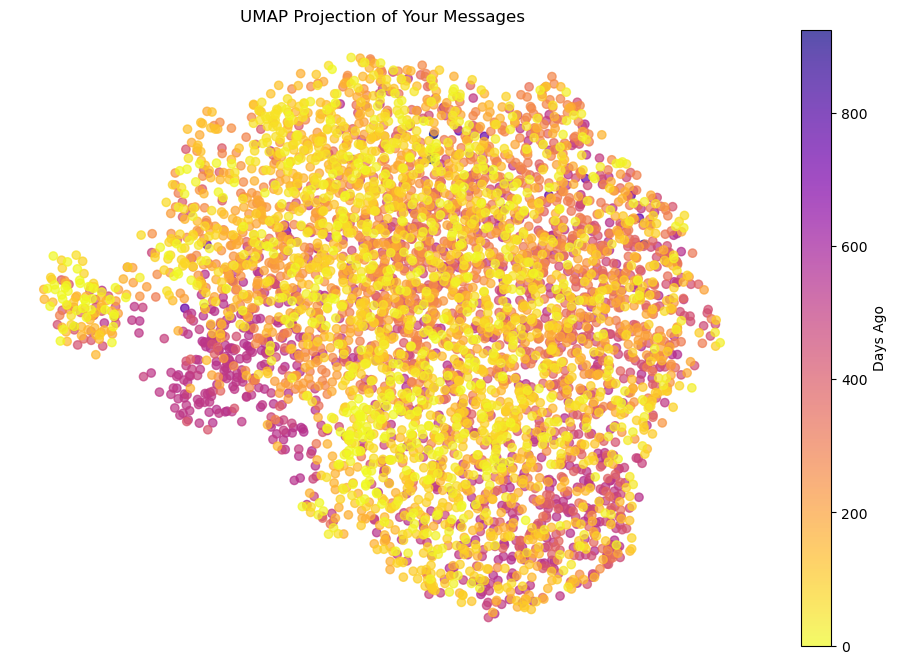

In [5]:
# Calculate how many days ago
now = datetime(2025, 7, 26) # Or any other fixed date you prefer
days_ago = [(now - dt).days for dt in timestamp_datetimes]

# Reduce dimensions
reducer = umap.UMAP(n_neighbors=100, min_dist=0.9, metric='cosine', random_state=3)
embedding_2d = reducer.fit_transform(embeddings)

# Build DataFrame (make sure to use cleaned_lines, not prompts!)
df_vis = pd.DataFrame(embedding_2d, columns=["UMAP 1", "UMAP 2"])
df_vis["message"] = cleaned_lines
df_vis["days_ago"] = days_ago

# Plot
plt.figure(figsize=(12, 8))
sc = plt.scatter(df_vis["UMAP 1"], df_vis["UMAP 2"], c=df_vis["days_ago"], cmap="plasma_r", alpha=0.7)
plt.colorbar(sc, label="Days Ago")
plt.title("UMAP Projection of Your Messages")
plt.axis('off')
plt.grid(False)
plt.show()


In [29]:
# KMeans clustering
n_clusters = 16
kmeans = KMeans(n_clusters=n_clusters, random_state=32)
labels = kmeans.fit_predict(embedding_2d)

# DataFrame
df_vis = pd.DataFrame(embedding_2d, columns=["UMAP 1", "UMAP 2"])
df_vis["message"] = cleaned_lines
df_vis["cluster"] = labels.astype(str)

# Moody glowing palette (deep, luminous tones)
neo_expressionist_palette = [
    "#F72585", "#7209B7", "#3A0CA3", "#4361EE", "#4CC9F0",  # magenta → cyan
    "#FFB703", "#FB8500", "#E63946", "#9A031E", "#5F0F40",  # hot yellows → red
    "#06D6A0", "#118AB2", "#073B4C", "#FFD6A5", "#FFADAD",  # cool aquas and pastels
    "#CDB4DB", "#FFAFCC", "#BDE0FE", "#A2D2FF", "#D9ED92"   # pale pastels
]

final_cluster_labels = {
    "0": "Interpersonal Dynamics<br> & <br>Emotional Introspection",
    "1": "Foundational Models<br> & <br>Advanced Deep Learning",
    "2": "Development tools:<br> Git, W&B, and Beyond",
    "3": "Professional <br>& <br>Academic Collaboration",
    "4": "Data Visualization",
    "5": "Scientific AI:<br> Superresolution & Beyond",
    "6": "Intellectual Firestorm:<br> AI & Philosophy",
    "7": "Surreal Visuals:<br> Dali, Magritte & the Mind",
    "8": "Data I/O & Debugging in Python",
    "9": "Existential Aestheticism:<br> Kurosawa to Camus",
    "10": "Orders & How-To's",
    "11": "Astrophysics: <br> From Telescopes to Dark Matter",
    "12": "Persian Literature<br> &<br> Cultural Nuance",
    "13": "Model Training<br> & <br>System Configuration",
    "14": "From Proposals<br> to<br> Philosophical Arguments",
    "15": "Polishing Prose <br> & <br> Perfecting Paragraphs"
}
# --- Cluster centers & labels ---
df_labels = (
    df_vis.groupby("cluster")[["UMAP 1", "UMAP 2"]]
    .mean()
    .reset_index()
)
df_labels["label"] = df_labels["cluster"].map(final_cluster_labels)

# --- Base scatter plot ---
fig = px.scatter(
    df_vis,
    x="UMAP 1",
    y="UMAP 2",
    color="cluster",
    custom_data=["message"],
    color_discrete_sequence=neo_expressionist_palette,
    title="🌌 ShoobAI: UMAP of Thoughts",
    opacity=0.4,
    height=1000
)

fig.update_traces(
    hovertemplate="<b>%{customdata[0]}</b><extra></extra>",
    marker=dict(size=6, line=dict(width=0.5, color='rgba(255, 255, 255, 0.6)'))
)

for cluster_num, label in final_cluster_labels.items():
    cluster_points = df_vis[df_vis["cluster"] == str(cluster_num)]
    x_median = cluster_points["UMAP 1"].median()
    y_median = cluster_points["UMAP 2"].median()

    fig.add_annotation(
        x=x_median,
        y=y_median,
        text=label,
        showarrow=False,
        font=dict(size=14, color="white"),
        align="center",
        borderpad=4,
        bgcolor="rgba(0,0,0,0.5)",  # semi-transparent dark box
        opacity=0.95
    )

fig.update_layout(
    xaxis=dict(showgrid=False, zeroline=False, visible=False),
    yaxis=dict(showgrid=False, zeroline=False, visible=False),
    plot_bgcolor='black',
    paper_bgcolor='black',
    font=dict(color='white'),
    title_font=dict(size=24),
    showlegend=False
)

import plotly.io as pio
pio.renderers.default = "browser"
fig.show()


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [51]:
# Save all messages with cluster numbers for manual review
output_file = "messages_with_clusters.txt"

with open(output_file, "w", encoding="utf-8") as f:
    for idx, row in df_vis.iterrows():
        cluster = row["cluster"]
        message = row["message"].replace("\n", " ").strip()
        f.write(f"{idx}\t{message}\n")

print(f"✅ Messages saved to {output_file}")


✅ Messages saved to messages_with_clusters.txt


In [57]:

# Define safe messages by index (example)
safe_message_indices = [4850, 4842, 4837, 4834, 4793, 4774, 4769, 4737, 4726, 4666,
                        4656, 4635, 4625, 4609, 4594, 4576, 4579, 4570, 4549, 4487, 
                        4489, 4485, 4440, 4417, 4401, 4380, 4375, 4376, 4378, 4347, 
                        4313, 4280, 4267, 4237, 4203, 4183, 4182, 4181, 4140, 4143, 
                        4062, 4061, 4056, 3989, 3920, 3908, 3870, 3854, 3786, 3771, 
                        3724, 3711, 3643, 3536, 3484, 3473, 3423, 3401, 3373, 
                        3339, 3245, 3235, 3213, 3206, 3167, 3150, 3153, 3152, 3108, 
                        3068, 2960, 2931, 2929, 2922, 2921, 2917, 2910, 2908, 2884, 
                        2847, 1893, 1952, 4485, 2350, 2501, 493, 2854,4371,1440, 
                        2159,683, 1327, 2155]
df_vis["safe_hover"] = [
    msg if i in safe_message_indices else "" for i, msg in enumerate(df_vis["message"])
]

import plotly.graph_objects as go

# --- Split data ---
safe_df = df_vis[df_vis["safe_hover"] != ""]
redacted_df = df_vis[df_vis["safe_hover"] == ""]

# --- Initialize plot ---
fig = go.Figure()

# --- Safe (visible + hoverable) layer ---
fig.add_trace(go.Scattergl(
    x=safe_df["UMAP 1"],
    y=safe_df["UMAP 2"],
    mode='markers',
    marker=dict(
        color=safe_df["cluster"].astype(int),
        colorscale=neo_expressionist_palette,
        size=7,
        opacity=0.75,
        line=dict(width=0.5, color='rgba(255,255,255,0.6)')
    ),
    text=safe_df["safe_hover"],
    hovertemplate="<b>%{text}</b><extra></extra>",
    name="Safe"
))

# --- Redacted (dim, not hoverable) layer ---
fig.add_trace(go.Scattergl(
    x=redacted_df["UMAP 1"],
    y=redacted_df["UMAP 2"],
    mode='markers',
    marker=dict(
        color=redacted_df["cluster"].astype(int),
        colorscale=neo_expressionist_palette,
        size=6,
        opacity=0.3
    ),
    hoverinfo='skip',
    name="Redacted"
))

# --- Add Cluster Labels ---
for cluster_num, label in final_cluster_labels.items():
    cluster_points = df_vis[df_vis["cluster"] == str(cluster_num)]
    x_median = cluster_points["UMAP 1"].median()
    y_median = cluster_points["UMAP 2"].median()

    fig.add_annotation(
        x=x_median,
        y=y_median,
        text=label,
        showarrow=False,
        font=dict(size=14, color="white"),
        align="center",
        borderpad=4,
        bgcolor="rgba(0,0,0,0.5)",
        opacity=0.95
    )

# --- Layout styling ---
fig.update_layout(
    plot_bgcolor="black",
    paper_bgcolor="black",
    font=dict(color="white"),
    showlegend=False,
    height=1000,
    xaxis=dict(visible=False),
    yaxis=dict(visible=False),
)

# Save the plot
pio.write_html(fig, "index.html")

In [17]:
# Save all 16 clusters to a text file
output_path = "shooby_umap_clusters.txt"

with open(output_path, "w", encoding="utf-8") as f:
    for cluster_id in sorted(df_vis["cluster"].unique(), key=int):  # ensures cluster numbers are ordered
        f.write(f"\n=== Cluster {cluster_id} ===\n")
        cluster_msgs = df_vis[df_vis["cluster"] == cluster_id]["message"].tolist()
        for msg in cluster_msgs[50:100]:
            f.write(f"{msg}\n")
